In [2]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src").exists():
        project_root = candidate
        break

if project_root is None:
    project_root = cwd

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import load_stock_data
from src.validation import validate_stock_data
from src.features import create_features
from src.target import create_target

In [3]:
df = load_stock_data("../data/raw/AAPL.csv")

print("Original shape:", df.shape)

Original shape: (10468, 7)


In [4]:
validate_stock_data(df)

print("Data validation passed.")

Data validation passed.


In [5]:
df = create_features(df)

print("Shape after feature engineering:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape after feature engineering: (10468, 24)

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Return_1D', 'Return_Lag_1', 'Return_Lag_2', 'Return_5D', 'Return_10D', 'Return_20D', 'Price_SMA20_Ratio', 'Price_SMA50_Ratio', 'Price_EMA20_Ratio', 'RSI_14', 'MACD_Norm', 'MACD_Hist', 'BB_%B', 'BB_Width', 'ATR_%', 'Volatility_20D', 'Relative_Volume']


In [6]:
df = create_target(df)

print(
    df[
        ["Date", "Close", "Target"]
    ].head(10)
)

        Date     Close  Target
0 1980-12-12  0.128348     0.0
1 1980-12-15  0.121652     0.0
2 1980-12-16  0.112723     1.0
3 1980-12-17  0.115513     1.0
4 1980-12-18  0.118862     1.0
5 1980-12-19  0.126116     1.0
6 1980-12-22  0.132254     1.0
7 1980-12-23  0.137835     1.0
8 1980-12-24  0.145089     1.0
9 1980-12-26  0.158482     1.0


In [7]:
feature_columns = [
    "Return_1D",
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_5D",
    "Return_10D",
    "Return_20D",
    "Price_SMA20_Ratio",
    "Price_SMA50_Ratio",
    "Price_EMA20_Ratio",
    "RSI_14",
    "MACD_Norm",
    "MACD_Hist",
    "BB_%B",
    "BB_Width",
    "ATR_%",
    "Volatility_20D",
    "Relative_Volume"
]

print("Number of candidate features:", len(feature_columns))

Number of candidate features: 17


In [8]:
print(
    df[
        feature_columns + ["Target"]
    ].isnull().sum()
)

Return_1D             1
Return_Lag_1          2
Return_Lag_2          3
Return_5D             5
Return_10D           10
Return_20D           20
Price_SMA20_Ratio    19
Price_SMA50_Ratio    49
Price_EMA20_Ratio     0
RSI_14               14
MACD_Norm             0
MACD_Hist             0
BB_%B                19
BB_Width             19
ATR_%                13
Volatility_20D       20
Relative_Volume      19
Target                1
dtype: int64


In [9]:
df = df.dropna(
    subset=feature_columns + ["Target"]
).reset_index(drop=True)

print("Shape after removing NaN rows:", df.shape)

Shape after removing NaN rows: (10418, 25)


In [10]:
print(
    df[
        ["Date"] +
        feature_columns +
        ["Target"]
    ].tail(10)
)

            Date  Return_1D  Return_Lag_1  Return_Lag_2  Return_5D  \
10408 2022-06-03  -0.038556      0.016811     -0.000873   0.011128   
10409 2022-06-06   0.005228     -0.038556      0.016811  -0.023389   
10410 2022-06-07   0.017586      0.005228     -0.038556  -0.000873   
10411 2022-06-08  -0.005043      0.017586      0.005228  -0.005043   
10412 2022-06-09  -0.035956     -0.005043      0.017586  -0.056676   
10413 2022-06-10  -0.038629     -0.035956     -0.005043  -0.056748   
10414 2022-06-13  -0.038285     -0.038629     -0.035956  -0.097578   
10415 2022-06-14   0.006673     -0.038285     -0.038629  -0.107256   
10416 2022-06-15   0.020111      0.006673     -0.038285  -0.084685   
10417 2022-06-16  -0.039651      0.020111      0.006673  -0.088194   

       Return_10D  Return_20D  Price_SMA20_Ratio  Price_SMA50_Ratio  \
10408    0.058464   -0.071292          -0.004966          -0.085327   
10409    0.062141   -0.070829           0.004064          -0.077333   
10410    0.03913

In [11]:
print(
    df[
        feature_columns + ["Target"]
    ].isnull().sum()
)

Return_1D            0
Return_Lag_1         0
Return_Lag_2         0
Return_5D            0
Return_10D           0
Return_20D           0
Price_SMA20_Ratio    0
Price_SMA50_Ratio    0
Price_EMA20_Ratio    0
RSI_14               0
MACD_Norm            0
MACD_Hist            0
BB_%B                0
BB_Width             0
ATR_%                0
Volatility_20D       0
Relative_Volume      0
Target               0
dtype: int64


In [12]:
print("Target counts:")
print(df["Target"].value_counts())

print("\nTarget proportions:")
print(
    df["Target"]
    .value_counts(normalize=True)
)

Target counts:
Target
0.0    5252
1.0    5166
Name: count, dtype: int64

Target proportions:
Target
0.0    0.504127
1.0    0.495873
Name: proportion, dtype: float64


In [13]:
print(
    df[feature_columns]
    .describe()
    .T
)

                     count       mean        std        min        25%  \
Return_1D          10418.0   0.001111   0.028297  -0.518692  -0.013007   
Return_Lag_1       10418.0   0.001116   0.028295  -0.518692  -0.012998   
Return_Lag_2       10418.0   0.001109   0.028299  -0.518692  -0.013007   
Return_5D          10418.0   0.005517   0.062796  -0.587617  -0.028776   
Return_10D         10418.0   0.011091   0.088707  -0.627737  -0.039317   
Return_20D         10418.0   0.022418   0.127356  -0.670336  -0.054098   
Price_SMA20_Ratio  10418.0   0.007891   0.070137  -0.569171  -0.030651   
Price_SMA50_Ratio  10418.0   0.020795   0.117313  -0.594971  -0.044235   
Price_EMA20_Ratio  10418.0   0.006463   0.061156  -0.527903  -0.026373   
RSI_14             10418.0  53.184815  13.084977  15.348959  43.603191   
MACD_Norm          10418.0   0.001572   0.038316  -0.491882  -0.012961   
MACD_Hist          10418.0   0.000094   0.010554  -0.187113  -0.004948   
BB_%B              10418.0   0.552052 

In [14]:
correlation = df[feature_columns].corr()

print(correlation)

                   Return_1D  Return_Lag_1  Return_Lag_2  Return_5D  \
Return_1D           1.000000      0.014230     -0.025778   0.443637   
Return_Lag_1        0.014230      1.000000      0.014227   0.438156   
Return_Lag_2       -0.025778      0.014227      1.000000   0.441691   
Return_5D           0.443637      0.438156      0.441691   1.000000   
Return_10D          0.311833      0.318068      0.312378   0.705839   
Return_20D          0.231561      0.234018      0.226440   0.514912   
Price_SMA20_Ratio   0.379788      0.365103      0.334773   0.760563   
Price_SMA50_Ratio   0.242024      0.240257      0.229058   0.520279   
Price_EMA20_Ratio   0.416368      0.383641      0.337438   0.774267   
RSI_14              0.320133      0.304774      0.275137   0.630532   
MACD_Norm           0.079480      0.126481      0.161084   0.339848   
MACD_Hist           0.177250      0.278242      0.323925   0.638447   
BB_%B               0.411408      0.364476      0.309480   0.724796   
BB_Wid

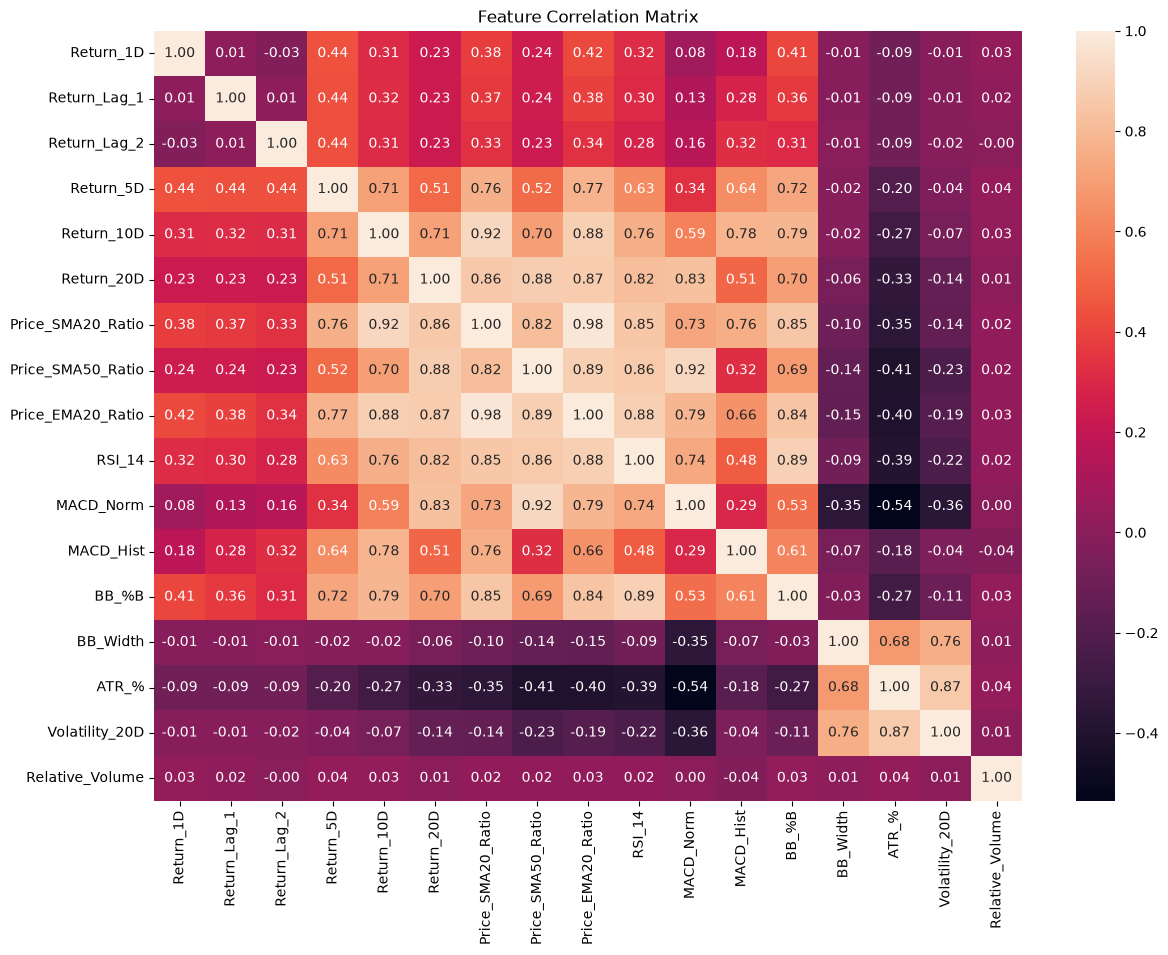

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [16]:
correlation = df[feature_columns].corr()

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):
        value = correlation.iloc[i, j]

        if abs(value) >= 0.80:
            print(
                feature_columns[i],
                "<->",
                feature_columns[j],
                ":",
                round(value, 3)
            )

Return_10D <-> Price_SMA20_Ratio : 0.916
Return_10D <-> Price_EMA20_Ratio : 0.883
Return_20D <-> Price_SMA20_Ratio : 0.861
Return_20D <-> Price_SMA50_Ratio : 0.876
Return_20D <-> Price_EMA20_Ratio : 0.87
Return_20D <-> RSI_14 : 0.815
Return_20D <-> MACD_Norm : 0.826
Price_SMA20_Ratio <-> Price_SMA50_Ratio : 0.82
Price_SMA20_Ratio <-> Price_EMA20_Ratio : 0.981
Price_SMA20_Ratio <-> RSI_14 : 0.855
Price_SMA20_Ratio <-> BB_%B : 0.85
Price_SMA50_Ratio <-> Price_EMA20_Ratio : 0.886
Price_SMA50_Ratio <-> RSI_14 : 0.865
Price_SMA50_Ratio <-> MACD_Norm : 0.92
Price_EMA20_Ratio <-> RSI_14 : 0.883
Price_EMA20_Ratio <-> BB_%B : 0.842
RSI_14 <-> BB_%B : 0.888
ATR_% <-> Volatility_20D : 0.865
